# FIAP - Inteligência Artificial (PBL)
## CardioIA: A Nova Era da Cardiologia Inteligente
### Fase 2: Diagnóstico Automatizado – IA no Estetoscópio Digital

* **Integrante:** Cauã Santos — **RM:** 566599
* **Objetivo:** Implementar um módulo inteligente de suporte à decisão clínica com duas frentes:
  1. Extração de sintomas a partir de texto livre e correlação ontológica com patologias cardiovasculares.
  2. Classificador estatístico de risco clínico (TF-IDF + Machine Learning) para triagem emergencial hospitalar, com foco em governança de dados e mitigação de vieses.

In [21]:
import os
import csv
import json
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuração de estilo visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


---
## Parte 1: Extração de Sintomas e Mapeamento Ontológico de Doenças

Nesta etapa, o sistema interpreta relatos em linguagem natural de pacientes, normaliza variações ortográficas e cruza os termos extraídos com uma base de conhecimento clínico estruturada com base nas diretrizes de:
* Síndrome Coronariana Aguda (SCA / IAM)
* Insuficiência Cardíaca (Critérios de Framingham)
* Fibrilação Atrial e Arritmias
* Hipertensão Arterial Sistêmica (HAS)

In [22]:
# 1. Resolução dos caminhos para a pasta data/
caminho_mapa = "../data/mapa_conhecimento.csv" if os.path.exists("../data/mapa_conhecimento.csv") else "data/mapa_conhecimento.csv"
caminho_frases = "../data/frases_sintomas.txt" if os.path.exists("../data/frases_sintomas.txt") else "data/frases_sintomas.txt"

# 2. Verificação da existência dos arquivos
if not os.path.exists(caminho_mapa):
    raise FileNotFoundError(f"Arquivo de mapa ontológico não encontrado em: {caminho_mapa}")
if not os.path.exists(caminho_frases):
    raise FileNotFoundError(f"Arquivo de frases clínicas não encontrado em: {caminho_frases}")

print(f"Arquivos clínicos identificados com sucesso:")
print(f"• Ontologia: {caminho_mapa}")
print(f"• Relatos médicos: {caminho_frases}")


Arquivos clínicos identificados com sucesso:
• Ontologia: data/mapa_conhecimento.csv
• Relatos médicos: data/frases_sintomas.txt


In [23]:
def normalizar_texto(texto: str) -> str:
    """Remove caracteres acentuados e converte para caixa baixa."""
    nfkd = unicodedata.normalize('NFKD', texto)
    sem_acento = "".join([c for c in nfkd if not unicodedata.combining(c)])
    return sem_acento.lower().strip()

def carregar_ontologia(caminho_csv: str) -> list:
    """Carrega as associações de sintomas e diagnósticos."""
    regras = []
    with open(caminho_csv, mode='r', encoding='utf-8') as f:
        leitor = csv.DictReader(f)
        for linha in leitor:
            regras.append({
                "s1_norm": normalizar_texto(linha["Sintoma 1"]),
                "s2_norm": normalizar_texto(linha["Sintoma 2"]),
                "s1_rotulo": linha["Sintoma 1"],
                "s2_rotulo": linha["Sintoma 2"],
                "diagnostico": linha["Doenca Associada"]
            })
    return regras

# Execução do pipeline de extração
caminho_mapa = "data/mapa_conhecimento.csv" if os.path.exists("data/mapa_conhecimento.csv") else "../data/mapa_conhecimento.csv"
caminho_frases = "data/frases_sintomas.txt" if os.path.exists("data/frases_sintomas.txt") else "../data/frases_sintomas.txt"

regras_clinicas = carregar_ontologia(caminho_mapa)

with open(caminho_frases, mode='r', encoding='utf-8') as f:
    relatos = [linha.strip() for linha in f if linha.strip()]

print("=" * 85)
print("CARDIOIA - EXTRAÇÃO DE ENTIDADES CLÍNICAS E INFERÊNCIA DIAGNÓSTICA")
print("=" * 85)

resultados_extracao = []

for idx, relato in enumerate(relatos, start=1):
    relato_norm = normalizar_texto(relato)
    sintomas_encontrados = []
    hipoteses = set()

    for r in regras_clinicas:
        s1_presente = r["s1_norm"] in relato_norm
        s2_presente = r["s2_norm"] in relato_norm

        if s1_presente:
            sintomas_encontrados.append(r["s1_rotulo"])
        if s2_presente:
            sintomas_encontrados.append(r["s2_rotulo"])

        if s1_presente or s2_presente:
            hipoteses.add(r["diagnostico"])

    sintomas_finais = sorted(list(set(sintomas_encontrados)))
    hipoteses_finais = sorted(list(hipoteses))

    resultados_extracao.append({
        "Paciente": f"Paciente {idx:02d}",
        "Relato": relato,
        "Sintomas": ", ".join(sintomas_finais) if sintomas_finais else "Nenhum",
        "Diagnósticos Sugeridos": ", ".join(hipoteses_finais) if hipoteses_finais else "Geral"
    })

    print(f"\n[Paciente {idx:02d}]")
    print(f"Texto: \"{relato}\"")
    print(f"-> Sintomas Mapeados: {sintomas_finais if sintomas_finais else 'Não detectado'}")
    print(f"-> Hipótese Diagnóstica: {hipoteses_finais if hipoteses_finais else 'Avaliação ambulatorial básica'}")
    print("-" * 85)

CARDIOIA - EXTRAÇÃO DE ENTIDADES CLÍNICAS E INFERÊNCIA DIAGNÓSTICA

[Paciente 01]
Texto: "Há dois dias venho sentindo uma dor no peito em aperto no tórax que piora quando subo escadas e me impede de trabalhar."
-> Sintomas Mapeados: ['aperto no torax', 'dor no peito']
-> Hipótese Diagnóstica: ['Sindrome Coronariana Aguda (IAM)']
-------------------------------------------------------------------------------------

[Paciente 02]
Texto: "Desde ontem à noite tenho falta de ar intensa e muita dificuldade para respirar ao deitar na cama, não conseguindo dormir."
-> Sintomas Mapeados: ['dificuldade para respirar', 'falta de ar']
-> Hipótese Diagnóstica: ['Insuficiencia Cardiaca Congestiva']
-------------------------------------------------------------------------------------

[Paciente 03]
Texto: "Sinto um cansaço constante há mais de uma semana com fadiga aos pequenos esforços, mal conseguindo varrer a casa."
-> Sintomas Mapeados: ['cansaco constante', 'fadiga']
-> Hipótese Diagnóstica: ['I

---
## Parte 2: Classificador de Triagem Textual com TF-IDF e Machine Learning

Simulação de um sistema de triagem inteligente (como o Protocolo de Manchester) para categorizar queixas clínicas em:
* **`alto risco`**: Sintomas indicativos de emergências cardiológicas com risco de vida iminente ou tempo-dependentes (ex.: IAM, choque cardiogênico, arritmias graves).
* **`baixo risco`**: Desconfortos leves, queixas osteomusculares, quadros respiratórios altos leves ou sintomas gastrointestinais transitórios.

### Pipeline:
1. Vetorização léxica com **TF-IDF** (Term Frequency - Inverse Document Frequency) utilizando unigramas e bigramas.
2. Modelo linear de **Regressão Logística** com regularização L2 e calibração probabilística.
3. Avaliação estatística completa (Acurácia, Precisão, Sensibilidade/Recall, F1-Score e Matriz de Confusão).

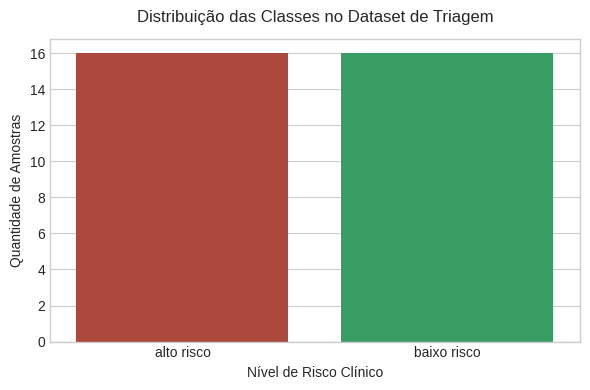

Total de registros carregados: 32
situacao
alto risco     16
baixo risco    16
Name: count, dtype: int64


In [24]:
# 1. Resolução do caminho do dataset de triagem clínica
caminho_triagem = "../data/triagem_risco.csv" if os.path.exists("../data/triagem_risco.csv") else "data/triagem_risco.csv"

if not os.path.exists(caminho_triagem):
    raise FileNotFoundError(f"Arquivo de triagem não encontrado em: {caminho_triagem}")

# 2. Carregamento do dataset pré-existente na pasta data/
df_triagem = pd.read_csv(caminho_triagem)

# 3. Inspeção e visualização da distribuição das classes
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_triagem, x='situacao', hue='situacao', palette=['#c0392b', '#27ae60'], legend=False, ax=ax)
ax.set_title("Distribuição das Classes no Dataset de Triagem", fontsize=12, pad=12)
ax.set_xlabel("Nível de Risco Clínico", fontsize=10)
ax.set_ylabel("Quantidade de Amostras", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total de registros carregados: {len(df_triagem)}")
print(df_triagem['situacao'].value_counts())


In [25]:
# Divisão Estratificada (75% Treino / 25% Teste)
X = df_triagem['frase']
y = df_triagem['situacao']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Lista de stop-words customizada para o domínio em língua portuguesa
stopwords_custom = [
    'a', 'ao', 'aos', 'as', 'com', 'da', 'das', 'de', 'do', 'dos', 'e', 
    'em', 'no', 'na', 'nos', 'nas', 'o', 'os', 'para', 'por', 'que', 'se', 'um', 'uma'
]

# Vetorização TF-IDF considerando unigramas e bigramas
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words=stopwords_custom, min_df=1)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Treinamento com Regressão Logística
modelo = LogisticRegression(random_state=42, C=1.0)
modelo.fit(X_train_tfidf, y_train)

print(f"Vocabulário extraído pelo TF-IDF: {len(vectorizer.get_feature_names_out())} termos/bigramas.")
print("Modelo de Regressão Logística treinado com sucesso.")

Vocabulário extraído pelo TF-IDF: 278 termos/bigramas.
Modelo de Regressão Logística treinado com sucesso.


Acurácia Geral no Conjunto de Teste: 87.50%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

  alto risco       0.80      1.00      0.89         4
 baixo risco       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



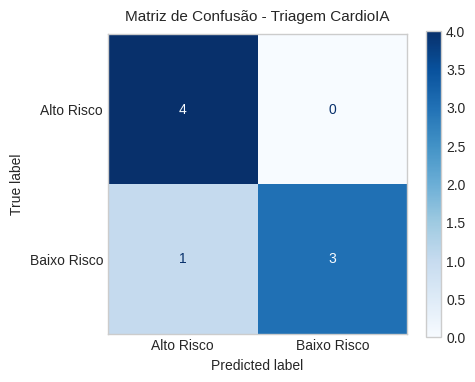

In [26]:
# Avaliação no conjunto de teste independente
y_pred = modelo.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)

print("=" * 70)
print(f"Acurácia Geral no Conjunto de Teste: {acc * 100:.2f}%")
print("=" * 70)
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred, labels=['alto risco', 'baixo risco']))

# Visualização da Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred, labels=['alto risco', 'baixo risco'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alto Risco', 'Baixo Risco'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title("Matriz de Confusão - Triagem CardioIA", fontsize=11, pad=10)
plt.grid(False)
plt.tight_layout()
plt.show()

In [27]:
# Extração dos coeficientes léxicos para Explicabilidade (Feature Importance)
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = modelo.coef_[0]

classe_pos = modelo.classes_[1]  # Ex: 'baixo risco'
classe_neg = modelo.classes_[0]  # Ex: 'alto risco'

top_n = 8
top_pos_idx = np.argsort(coefs)[-top_n:]
top_neg_idx = np.argsort(coefs)[:top_n]

print("=" * 75)
print("INTERPRETABILIDADE: TERMOS COM MAIOR PESO DECISÓRIO")
print("=" * 75)
print(f"Termos que mais pesam para [{classe_neg.upper()}]:")
for idx in top_neg_idx:
    print(f"  • {feature_names[idx]:<25} (peso: {coefs[idx]:.4f})")

print(f"\nTermos que mais pesam para [{classe_pos.upper()}]:")
for idx in reversed(top_pos_idx):
    print(f"  • {feature_names[idx]:<25} (peso: {coefs[idx]:.4f})")

INTERPRETABILIDADE: TERMOS COM MAIOR PESO DECISÓRIO
Termos que mais pesam para [ALTO RISCO]:
  • forte                     (peso: -0.2704)
  • falta                     (peso: -0.2654)
  • falta ar                  (peso: -0.2654)
  • ar                        (peso: -0.2654)
  • peito                     (peso: -0.2548)
  • subita                    (peso: -0.2094)
  • dor                       (peso: -0.1968)
  • palidez                   (peso: -0.1901)

Termos que mais pesam para [BAIXO RISCO]:
  • apos                      (peso: 0.4656)
  • leve                      (peso: 0.4247)
  • final                     (peso: 0.2025)
  • ou                        (peso: 0.1842)
  • sem                       (peso: 0.1842)
  • bater                     (peso: 0.1206)
  • dorzinha                  (peso: 0.1206)
  • dorzinha passageira       (peso: 0.1206)


In [28]:
# Simulação em tempo real com novos relatos clínicos não vistos no treino
casos_novos = [
    "Estou sentindo um aperto forte no peito e muito suor frio desde cedo",
    "Apenas uma dor leve nas costas que apareceu depois de correr",
    "Muita falta de ar ao deitar com tosse e o peito pesado",
    "Tive azia depois de comer pizza no jantar de ontem",
    "Estou com fraqueza súbita, palpitação muito forte e escurecimento na vista",
    "Sinto um incômodo no braço esquerdo e queimação no estômago há horas"
]

X_novos_tfidf = vectorizer.transform(casos_novos)
predicoes = modelo.predict(X_novos_tfidf)
probabilidades = modelo.predict_proba(X_novos_tfidf)

print("=" * 85)
print("INFERÊNCIA EM TEMPO REAL: SIMULAÇÃO DE TRIAGEM COM PROBABILIDADE")
print("=" * 85)

for frase, pred, probs in zip(casos_novos, predicoes, probabilidades):
    idx_classe = list(modelo.classes_).index(pred)
    certeza = probs[idx_classe] * 100
    
    # Cores indicativas no terminal
    tag_risco = f"[{pred.upper()}]"
    print(f"Relato do Paciente: \"{frase}\"")
    print(f"Classificação Prevista: {tag_risco} (Grau de Certeza: {certeza:.2f}%)")
    print(f"Detalhamento: Alto Risco = {probs[0]*100:.1f}% | Baixo Risco = {probs[1]*100:.1f}%")
    print("-" * 85)

INFERÊNCIA EM TEMPO REAL: SIMULAÇÃO DE TRIAGEM COM PROBABILIDADE
Relato do Paciente: "Estou sentindo um aperto forte no peito e muito suor frio desde cedo"
Classificação Prevista: [ALTO RISCO] (Grau de Certeza: 59.64%)
Detalhamento: Alto Risco = 59.6% | Baixo Risco = 40.4%
-------------------------------------------------------------------------------------
Relato do Paciente: "Apenas uma dor leve nas costas que apareceu depois de correr"
Classificação Prevista: [BAIXO RISCO] (Grau de Certeza: 54.99%)
Detalhamento: Alto Risco = 45.0% | Baixo Risco = 55.0%
-------------------------------------------------------------------------------------
Relato do Paciente: "Muita falta de ar ao deitar com tosse e o peito pesado"
Classificação Prevista: [ALTO RISCO] (Grau de Certeza: 59.78%)
Detalhamento: Alto Risco = 59.8% | Baixo Risco = 40.2%
-------------------------------------------------------------------------------------
Relato do Paciente: "Tive azia depois de comer pizza no jantar de ontem

---
## Análise Crítica: Governança, Vieses e Segurança do Paciente

### 1. Assimetria Crítica dos Erros Médicos (Falsos Negativos vs. Falsos Positivos)
* **Falso Negativo (Risco Crítico):** Classificar um paciente com Síndrome Coronariana Aguda (IAM) como `baixo risco`. Esse erro retarda o tempo porta-balão (< 90 min) ou tempo porta-agulha (< 30 min), levando a necrose miocárdica irreversível ou óbito. Otimizações de hiperparâmetros devem priorizar o **Recall** (Sensibilidade) da classe `alto risco`.
* **Falso Positivo (Sobrecarga Operacional):** Classificar uma mialgia como `alto risco`. Gera fila no eletrocardiograma e exames laboratoriais, mas preserva a vida do paciente.

### 2. Vieses Amostrais e Manifestações Clínicas Atípicas
* Conforme mapeado nas diretrizes clínicas da Fase 1, populações como **mulheres, idosos e pessoas com diabetes** frequentemente não apresentam a clássica "dor no peito em aperto".
* Nesses grupos, o quadro isquêmico manifesta-se através de equivalentes anginosos: dispneia isolada, náuseas, astenia extrema e queimação epigástrica.
* Um modelo puramente lexical pode falhar se supervalorizar palavras como *"peito"* ou *"tórax"* e ignorar sintomas atípicos, reproduzindo viés histórico de subdiagnóstico.

### 3. Governança e LGPD
* O CardioIA atua como ferramenta de **suporte à decisão clínica** (estetoscópio digital) e nunca como instância substitutiva do diagnóstico médico.
* Todos os dados textuais de prontuário devem passar por procedimentos de anonimização (remoção de nomes, CPF, idade exata e datas de internação) em conformidade com a LGPD (Lei 13.709/2018).